# Дополнение к Python Core

### Декораторы

```
Декоратор — это способ обернуть функцию (или класс) и изменить её поведение, не меняя код обернутого объекта.
```

In [4]:
def printing_decorator(target_function):
    print(f'Init decorator for func: {target_function.__name__}')

    def inner_func(*args, **kwargs):
        target_function(*args, **kwargs)

    return inner_func


def simple_function(text):
    print(text)

simple_function('Pen')

Pen


#### Как это работает?

In [5]:
(printing_decorator(simple_function))('Apple')

Init decorator for func: simple_function
Apple


#### Декоратор для логирования

In [7]:
import datetime

def current_time():
    return datetime.datetime.now().strftime("%M:%S.%f")


def logging_time(target_function):
    print(f'Init decorator for func: {target_function.__name__}')

    def inner_func(*args, **kwargs):
        print(f'{current_time()} - Start func: {target_function.__name__}')
        target_function(*args, **kwargs)
        print(f'{current_time()} - End func: {target_function.__name__}')

    return inner_func

In [8]:
@logging_time
def decorated_function(text):
    print(text)


decorated_function('--- Pen')
print('\n')
decorated_function('--- Pineapple')

Init decorator for func: decorated_function
21:33.132121 - Start func: decorated_function
--- Pen
21:33.132213 - End func: decorated_function


21:33.132405 - Start func: decorated_function
--- Pineapple
21:33.132428 - End func: decorated_function


#### Декоратор с параметрами

In [12]:
from functools import wraps

def printing_with_parameters(decor_arg=''):
    print('- decor_arg:', decor_arg)
    def inner(target_function):
        print(f'-- Init for {target_function.__name__}')

        @wraps(target_function)
        def wrapper(*args):
            print('--- Before decor func')
            target_function(*args)
            print('--- After decor func')
    
        return wrapper
    return inner


@printing_with_parameters(decor_arg='PPAP')
def decorated_function_2(*args):
    print(args)

print(decorated_function_2.__name__)

decorated_function_2('Pen', 'Pineapple', 'Apple', 'Pen')

- decor_arg: PPAP
-- Init for decorated_function_2
decorated_function_2
--- Before decor func
('Pen', 'Pineapple', 'Apple', 'Pen')
--- After decor func


# Подготовка

> Для установки дополнительных библиотек используем утилиту `pip` (менеджер пакетов)

In [79]:
%pip install pandas numpy plotly aiohttp ipywidgets requests nbformat


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [80]:
# функция для вывода текущего времени

import datetime

def print_wt(prefix, postfix=''):
    current_time = datetime.datetime.now().strftime("%M:%S.%f")

    print(f"{current_time} | {prefix} {postfix}")

print_wt("Какой-то текст")

21:50.377745 | Какой-то текст 


## Важные концепции

### Generators (генераторы)

```
Генератор – это функция, которая возвращает итератор генератора. Или же функция, которая просто содержит "yield"
```

In [15]:
def generator_1():
    yield "a"
    yield "b"
    yield "c"

In [17]:
generator_1()

<generator object generator_1 at 0x106701cc0>

In [18]:
for v in generator_1():
     print(v)

a
b
c


```
Генераторы – ленивые. Это значит, что каждое значение будет вычислено только в тот момент, когда оно потребуется
```

In [19]:
def generator_with_printing_time():
    print_wt("before a")
    yield "a"
    print_wt("before b")
    yield "b"
    print_wt("before c")
    yield "c"

In [21]:
gen = generator_with_printing_time()
gen

<generator object generator_with_printing_time at 0x106701b40>

In [22]:
next(gen)

29:18.051655 | before a 


'a'

In [23]:
next(gen)

29:35.611224 | before b 


'b'

In [25]:
next(gen)

StopIteration: 

### List-comprehensions и generator expressions (списочные и генераторные выражения)

In [26]:
l = [1, 2, 3, 4, 5]

##### Представьте, что мы хотим умножить все значения в списке на 2, что для этого нужно сделать?

In [27]:
new_list = []
for item in l:
    new_list.append(item * 2)
    
new_list

[2, 4, 6, 8, 10]

##### Но есть способ эффективнее:

In [28]:
new_list = [x * 2 for x in l]
print(new_list)

[2, 4, 6, 8, 10]


In [30]:
new_list = list(map(lambda x: x * 2, l))
print(new_list)

##### Можно использовать тернарный оператор 

In [31]:
new_list = [item * 2 for item in l if item % 2 == 0]
new_list

[4, 8]

### Ещё про генераторы

In [32]:
def unbounded_generator():
    number = 0
    try:
        while True:
            number+=1
            yield number
        
    except KeyboardInterrupt:
        yield "Whoa, we out of the loop"

gen = unbounded_generator()
next(gen)

1

In [33]:
gen_list = list(gen)

In [34]:
print(len(gen_list))

77135128


##### Какое будет значение? 

In [37]:
print(gen_list[-2])

77135128


In [38]:
gen_list[0]

2

### Coroutines (корутины)

```
Корутины (сопрограммы) – это части программы, которые имеют возможность остановить и продолжить выполнение, взаимодействовать с другими частями программы. За счёт этих свойств они помогают реализовать невытесняющую (кооперативную) многозадачность.
```

In [39]:
def setup():
    print('Start')
    data = None
    print('step1', data)
    data = yield 1
    print('step2', data)
    data = yield 0
    print('step3', data)

coro = setup()
coro

<generator object setup at 0x1074dde50>

In [40]:
next(coro)

Start
step1 None


1

In [43]:
result = coro.send("new value2")

step3 new value2


StopIteration: 

In [42]:
result

0

### Ещё раз для наглядности

![Alt text](https://blog.skillfactory.ru/wp-content/uploads/2023/02/coroutine1-3919182.png "Отличие корутины от функции")

### внимание вопрос:

# Нужен перерыв?

# "Настоящие" корутины (asyncio)

> В python 3.5 появились нативные корутины, с ними удобнее работать, но смысл у них тот же.
До python 3.5 вся асинхронность работала именно на таких корутинах, которые мы смотрели выше.

https://docs.python.org/3/library/asyncio-task.html

In [44]:
import asyncio
import time

In [45]:
def no_coro():
    print_wt("- Start of no_coro")
    time.sleep(3)
    print_wt("- End of no_coro")


async def coro(id=0):
    print_wt(f"- Start of coro with id={id}")
    await asyncio.sleep(3)
    print_wt(f"- End of coro with id={id}")

In [49]:
async def main():
    print_wt("Start of main")
    # no_coro()
    await coro()
    print_wt("End of main")

# В ноутбуке ненужно, но обычно требуется вызвать, чтобы запустить event_loop:
# asyncio.run(main())
await main()


55:23.240292 | Start of main 
55:23.241648 | - Start of coro with id=0 
55:26.242907 | - End of coro with id=0 
55:26.243179 | End of main 


### Корутина с результатом

In [50]:
async def coro_with_result(x):
    print_wt(f"- Start of 'coro_with_result' with value = {x}")
    await asyncio.sleep(3)
    print_wt(f"- End of 'coro_with_result' with value = {x}")
    return x * x

In [51]:
print("Start of main")
x = await coro_with_result(7)
print("End of main", x)

Start of main
56:09.197526 | - Start of 'coro_with_result' with value = 7 
56:12.198669 | - End of 'coro_with_result' with value = 7 
End of main 49


### Конкурентный запуск через Task

> Task (задача) - это такой объект, предназначенные для независимого планирования и выполнения корутин. Задача позволяет ставить задачи в очередь, отменять их и получать в нужное время результаты их работы и выданные ими исключения

In [52]:
async def coro_with_result(x):
    print_wt(f"- Start of 'coro_with_result' with value = {x}")
    await asyncio.sleep(5)
    print_wt(f"- End of 'coro_with_result' with value = {x}")
    return x * x

In [64]:
print_wt("Start of main")
print_wt("init task1")
task1 = asyncio.create_task(coro_with_result(1))
print_wt("after init task1")
print(type(task1))

await asyncio.sleep(0)  # ?

print_wt("init task2")
task2 = asyncio.create_task(coro_with_result(2))
print_wt("after init task2")

await asyncio.sleep(0)
print_wt("-- Before cancellation task1")
task1.cancel()

await asyncio.sleep(6)
print_wt("End of main")

# await task1s
result = await task2
print(result)


'''
02:19.628421 | Start of main 
02:19.628560 | init task1 
02:19.628939 | after init task1 
<class '_asyncio.Task'>
02:19.629104 | init task2 
02:19.629198 | after init task2 
02:19.629490 | - Start of 'coro_with_result' with value = 1 
02:19.629585 | - Start of 'coro_with_result' with value = 2 
02:19.629799 | -- Before cancellation task1 
02:24.630374 | - End of 'coro_with_result' with value = 2 
02:25.631124 | End of main 
4
'''

12:58.885344 | Start of main 
12:58.887284 | init task1 
12:58.887483 | after init task1 
<class '_asyncio.Task'>
12:58.887762 | - Start of 'coro_with_result' with value = 1 
12:59.888182 | init task2 
12:59.888552 | after init task2 
12:59.888884 | - Start of 'coro_with_result' with value = 2 
12:59.889088 | -- Before cancellation task1 
13:04.889488 | - End of 'coro_with_result' with value = 2 
13:05.890546 | End of main 
4


"\n02:19.628421 | Start of main \n02:19.628560 | init task1 \n02:19.628939 | after init task1 \n<class '_asyncio.Task'>\n02:19.629104 | init task2 \n02:19.629198 | after init task2 \n02:19.629490 | - Start of 'coro_with_result' with value = 1 \n02:19.629585 | - Start of 'coro_with_result' with value = 2 \n02:19.629799 | -- Before cancellation task1 \n02:24.630374 | - End of 'coro_with_result' with value = 2 \n02:25.631124 | End of main \n4\n"

### Task-object можно проверять на завершение

Есть методы:
* done() - проверка завершения
* result() - результат завершения
* exception() - ошибки при выполнении
* ...

In [57]:
async def coro_with_waiting(x: int):
    print_wt(f"- Start of 'coro_with_result' with value = {x}")
    await asyncio.sleep(x)
    print_wt(f"- End of 'coro_with_result' with value = {x}")
    return x * x

#### Повторим. Почему такая последовательность вывода?

In [58]:
task = asyncio.create_task(coro_with_waiting(4))
while not task.done():
    print_wt("Waiting")
    await asyncio.sleep(1)

print(task.result())
print(task.result())  # можно много раз запрашивать результат
print(task.result())

04:08.849823 | Waiting 
04:08.850146 | - Start of 'coro_with_result' with value = 4 
04:09.851061 | Waiting 
04:10.852331 | Waiting 
04:11.853333 | Waiting 
04:12.851583 | - End of 'coro_with_result' with value = 4 
16
16
16


### А если нужно запустить и подождать сразу несколько задач?

In [59]:
task1 = asyncio.create_task(coro_with_waiting(5))
task2 = asyncio.create_task(coro_with_waiting(1))
res = asyncio.gather(coro_with_waiting(4), task1, task2)

await res
print(res.result())

06:56.686216 | - Start of 'coro_with_result' with value = 5 
06:56.686764 | - Start of 'coro_with_result' with value = 1 
06:56.686832 | - Start of 'coro_with_result' with value = 4 
06:57.687864 | - End of 'coro_with_result' with value = 1 
07:00.687154 | - End of 'coro_with_result' with value = 4 
07:01.687790 | - End of 'coro_with_result' with value = 5 
[16, 25, 1]


### TaskGroup

> Лучше подходит, когда есть зависимость между задач

In [60]:
async with asyncio.TaskGroup() as tg:
    task1 = tg.create_task(coro_with_waiting(4))
    task2 = tg.create_task(coro_with_waiting(2))
    task3 = tg.create_task(coro_with_waiting(5))
print(task1.result(), task2.result())

09:06.085728 | - Start of 'coro_with_result' with value = 4 
09:06.085939 | - Start of 'coro_with_result' with value = 2 
09:06.085968 | - Start of 'coro_with_result' with value = 5 
09:08.094927 | - End of 'coro_with_result' with value = 2 
09:10.087047 | - End of 'coro_with_result' with value = 4 
09:11.087050 | - End of 'coro_with_result' with value = 5 
16 4


# Примеры

### Импортируем нужные модули

Модуль для отображения графиков

In [81]:
import plotly.express as px  # type: ignore

Так же будем подсчитывать время, которое занимают тестовые задачи, используем для этого

In [82]:
import datetime
import time

> Это обычная структура данных - [очередь](https://docs.python.org/3/library/queue.html)

In [83]:
import queue

#### Отображение графиков

В примерах мы будем формировать списки словарей вида:
```py
{
    'task_name': 'coroutine-4',
    'start': datetime.datetime(2022, 1, 22, 9, 18, 37, 281390),
    'end': datetime.datetime(2022, 1, 22, 9, 18, 37, 281625),
    'text': 2s
}
```
Давайте напишем функцию, которая на их основе построит график продолжительности выполнения различных тестовых задач

In [84]:
def print_timings(timeline):
    fig = px.timeline(timeline, x_start="start", x_end="end", y="name", color="name", text='text')
    fig.show()

## Пример 1: Обработка блокирующих задач

Описание:
  * Есть 6 задач (работ), которые необходимо выполнить  
  * Порядок выполнение задач не важен  
  * Решают эти задачи сразу 3 корутины (они же сопрограммы, работника) 

Ограничения:
  * нельзя выполнять эти задачи одновременно (они требуют больших вычислительных ресурсов)

Посмотрим на функции, которые нам помогут:

In [67]:
def blocked_coro(queue, name):
    print_wt(f"{name} Start")
    global timeline
    
    while not queue.empty():
        delay = queue.get()
        start_time = datetime.datetime.now()
        print_wt(f'{name} "working" for {delay} sec')
        time.sleep(delay)
        timeline.append({'name': name, 'start': start_time, 'end': datetime.datetime.now(), 'text': f'{delay}s'})
        yield
        
    print_wt(f'{name} Finish')

In [68]:
def multitasking_with_blocking_calls():
    work_queue = queue.Queue()
    for work in [3, 1, 4, 1, 3, 2]:  # сумма 14
        work_queue.put(work)

    coroutines = [blocked_coro(work_queue, f'coroutine-{i}') for i in range(3)]
    
    print_wt('Work started')
    
    # Run the tasks
    while len(coroutines):
        for coroutine in coroutines.copy():
            try:
                next(coroutine)
            except StopIteration:
                coroutines.remove(coroutine)
    print_wt(f'Work finished')

#### Запускаем пример

In [74]:
timeline = []
multitasking_with_blocking_calls()
print_timings(timeline)

20:08.099417 | Work started 
20:08.099495 | coroutine-0 Start 
20:08.099510 | coroutine-0 "working" for 3 sec 
20:11.099792 | coroutine-1 Start 
20:11.099975 | coroutine-1 "working" for 1 sec 
20:12.103922 | coroutine-2 Start 
20:12.104046 | coroutine-2 "working" for 4 sec 
20:16.108283 | coroutine-0 "working" for 1 sec 
20:17.112262 | coroutine-1 "working" for 3 sec 
20:20.116200 | coroutine-2 "working" for 2 sec 
20:22.121360 | coroutine-0 Finish 
20:22.121494 | coroutine-1 Finish 
20:22.121506 | coroutine-2 Finish 
20:22.121517 | Work finished 


## Пример 2: Асинхронная обработка неблокирующих задач

Описание:
  * как и в Примере 1

Ограничения:
  * можно выполнять задачи одновременно (не требуют больших вычислительных ресурсов)

In [75]:
# Нам потребуется дополнильный импорт

import asyncio

Посмотрим, что изменилось в функциях:

In [76]:
async def async_coro(queue, name):
    print_wt(f"{name} Start")
    global timeline

    while not queue.empty():
        delay = await queue.get()
        start_time = datetime.datetime.now()
        print_wt(f'{name} "working" for {delay} sec')
        await asyncio.sleep(delay)
        timeline.append({'name': name, 'start': start_time, 'end': datetime.datetime.now(), 'text': f'{delay}s'})

    print_wt(f'{name} Finish')

In [77]:
async def async_multitasking():
    work_queue = asyncio.Queue()
    for work in [3, 1, 4, 1, 3, 2]:
        await work_queue.put(work)
    
    print_wt(f'Work started')
    
    # Run the tasks
    await asyncio.gather(
        *[async_coro(work_queue, f'coroutine-{i}') for i in range(3)]
    )

    print_wt(f'Work finished')

#### Запускаем пример

In [78]:
timeline = []
await async_multitasking()
print_timings(timeline)

21:07.562172 | Work started 
21:07.563197 | coroutine-0 Start 
21:07.563279 | coroutine-0 "working" for 3 sec 
21:07.563310 | coroutine-1 Start 
21:07.563323 | coroutine-1 "working" for 1 sec 
21:07.563342 | coroutine-2 Start 
21:07.563352 | coroutine-2 "working" for 4 sec 
21:08.565316 | coroutine-1 "working" for 1 sec 
21:09.566048 | coroutine-1 "working" for 3 sec 
21:10.564896 | coroutine-0 "working" for 2 sec 
21:11.564467 | coroutine-2 Finish 
21:12.566478 | coroutine-0 Finish 
21:12.567806 | coroutine-1 Finish 
21:12.567912 | Work finished 


## Пример 3: Блокирующие HTTP вызовы

Описание:
  * как и в Примере 1, но делаем запросы к реальным сайтам

Ограничения:
  * запросы блокирующие (нельзя делать следующий, пока не завершится предыдущий)

In [85]:
# Библиотека для запросов по сети

import requests # type: ignore

In [86]:
def http_coro(queue, name):
    print_wt(f'{name} Start')
    global timeline
    
    with requests.Session() as session:
        while not queue.empty():
            url = queue.get()
            start_time = datetime.datetime.now()
            print_wt(f'{name}  getting URL: {url}')
            session.get(url, timeout=7)
            timeline.append({'name': name, 'start': start_time, 'end': datetime.datetime.now(), 'text': f'{url}'})
            yield
        
    print_wt(f'{name} Finish')

In [87]:
def blocking_http():
    work_queue = queue.Queue()
    for url in [
        "http://google.com",
        "http://yahoo.com",
        "http://apple.com",
        "http://microsoft.com",
        "http://codeforces.com",
        "http://hh.ru",
        "http://youtube.com",
        "http://www.github.com",
        "http://www.nekretnine.rs",
        "http://www.ford.com",
    ]:
        work_queue.put(url)
        
    coroutines = [http_coro(work_queue, f'coroutine-{i}') for i in range(3)]
    
    print_wt('Work started')
        
    # Run the tasks
    while len(coroutines):
        for coroutine in coroutines.copy():
            try:
                next(coroutine)
            except StopIteration:
                coroutines.remove(coroutine)
    print_wt('Work finished')

#### Запускаем пример

23:37.681745 | Work started 
23:37.681812 | coroutine-0 Start 
23:37.682174 | coroutine-0  getting URL: http://google.com 
23:38.823404 | coroutine-1 Start 
23:38.825329 | coroutine-1  getting URL: http://yahoo.com 
23:39.352559 | coroutine-2 Start 
23:39.352807 | coroutine-2  getting URL: http://apple.com 
23:39.701528 | coroutine-0  getting URL: http://microsoft.com 
23:40.093531 | coroutine-1  getting URL: http://codeforces.com 
23:41.287088 | coroutine-2  getting URL: http://hh.ru 
23:42.071560 | coroutine-0  getting URL: http://youtube.com 
23:43.145538 | coroutine-1  getting URL: http://www.github.com 
23:43.400597 | coroutine-2  getting URL: http://www.nekretnine.rs 
23:44.578178 | coroutine-0  getting URL: http://www.ford.com 
23:46.004734 | coroutine-1 Finish 
23:46.008467 | coroutine-2 Finish 
23:46.010397 | coroutine-0 Finish 
23:46.010448 | Work finished 


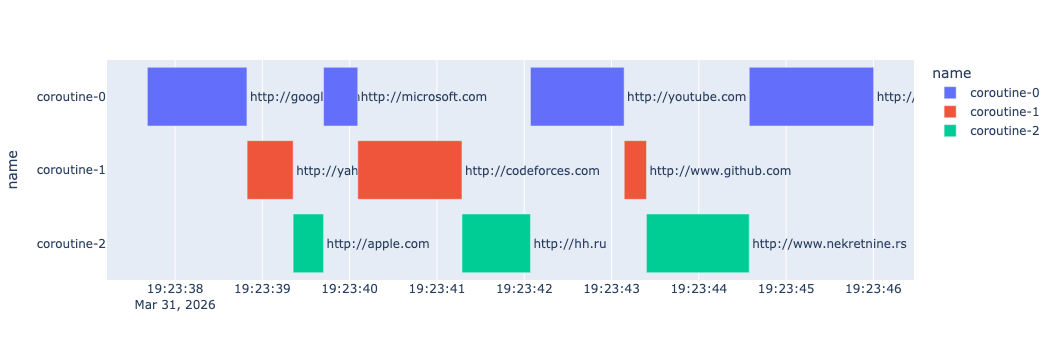

In [88]:
timeline = []
blocking_http()
print_timings(timeline)

## Пример 4: Неблокирующие HTTP вызовы

Описание:
  * как и в Примере 1, но делаем запросы к реальным сайтам

Ограничения:
  * запросы не блокируют друг друга

In [89]:
# Библиотека для асинхронных сетевых запросов

import aiohttp # type: ignore

In [90]:
async def async_http_coro(queue, name):
    print_wt(f'{name} Start')
    global timeline
    
    async with aiohttp.ClientSession() as session:
        while not queue.empty():
            url = await queue.get()
            start_time = datetime.datetime.now()
            print_wt(f'{name} getting URL: {url}')
            async with session.get(url, timeout=7) as response:
                text = await response.text()
            timeline.append({'name': name, 'start': start_time, 'end': datetime.datetime.now(), 'text': f'{url}'})

    print_wt(f'{name} Finish')

In [91]:
async def async_http():
    work_queue = asyncio.Queue()
    for url in [
        "http://google.com",
        "http://yahoo.com",
        "http://apple.com",
        "http://microsoft.com",
        "http://codeforces.com",
        "http://hh.ru",
        "http://youtube.com",
        "http://www.github.com",
        "http://www.nekretnine.rs",
        "http://www.ford.com",
    ]:
        await work_queue.put(url)
    
    print_wt('Work started')
    
    # Run the tasks
    await asyncio.gather(
        *[async_http_coro(work_queue, f'coroutine-{i}') for i in range(3)]
    )
    print_wt('Work finished')

#### Запускаем пример

24:03.207882 | Work started 
24:03.208021 | coroutine-0 Start 
24:03.209007 | coroutine-0 getting URL: http://google.com 
24:03.209791 | coroutine-1 Start 
24:03.209867 | coroutine-1 getting URL: http://yahoo.com 
24:03.210262 | coroutine-2 Start 
24:03.210307 | coroutine-2 getting URL: http://apple.com 
24:03.496245 | coroutine-2 getting URL: http://microsoft.com 
24:03.721158 | coroutine-1 getting URL: http://codeforces.com 
24:03.781963 | coroutine-2 getting URL: http://hh.ru 
24:04.422581 | coroutine-1 getting URL: http://youtube.com 
24:04.891929 | coroutine-0 getting URL: http://www.github.com 
24:05.049907 | coroutine-0 getting URL: http://www.nekretnine.rs 
24:05.478971 | coroutine-1 getting URL: http://www.ford.com 
24:05.582975 | coroutine-2 Finish 
24:05.722794 | coroutine-1 Finish 
24:07.339489 | coroutine-0 Finish 
24:07.339816 | Work finished 


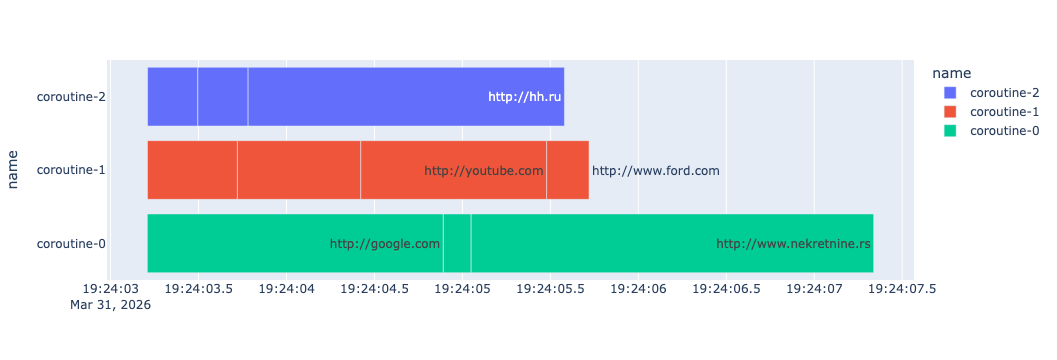

In [92]:
timeline = []
await async_http()
print_timings(timeline)